In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

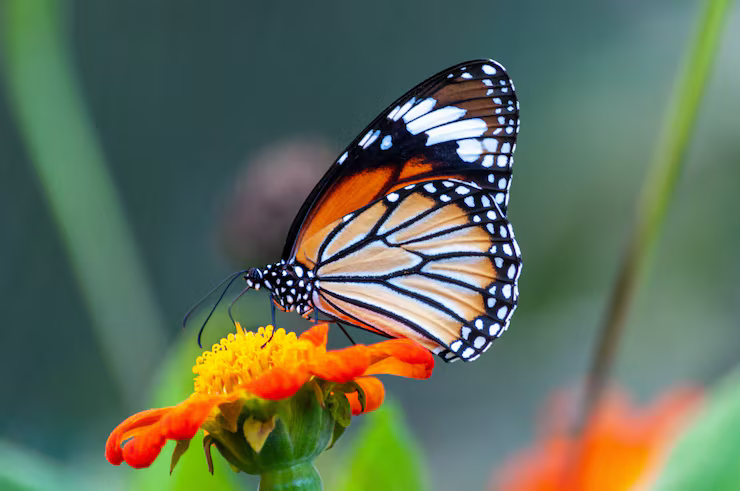

In [3]:
img = Image.open('butterfly.png')
img

In [4]:
pixel_data = np.asarray(img)
pixel_data

array([[[ 73, 111,  74],
        [ 73, 111,  74],
        [ 74, 112,  73],
        ...,
        [131, 164, 157],
        [129, 164, 157],
        [129, 164, 157]],

       [[ 73, 111,  74],
        [ 73, 111,  74],
        [ 74, 112,  73],
        ...,
        [131, 164, 157],
        [129, 164, 157],
        [130, 165, 158]],

       [[ 73, 111,  74],
        [ 73, 111,  74],
        [ 74, 112,  73],
        ...,
        [131, 164, 157],
        [130, 165, 158],
        [130, 165, 158]],

       ...,

       [[ 62, 145,  91],
        [ 62, 145,  91],
        [ 62, 145,  91],
        ...,
        [ 86, 181,  97],
        [ 87, 181,  95],
        [ 87, 181,  95]],

       [[ 61, 144,  90],
        [ 61, 144,  90],
        [ 61, 144,  90],
        ...,
        [ 86, 181,  97],
        [ 87, 181,  95],
        [ 88, 182,  96]],

       [[ 60, 143,  87],
        [ 60, 143,  87],
        [ 60, 143,  87],
        ...,
        [ 86, 182,  95],
        [ 86, 182,  93],
        [ 87, 183,  94]]

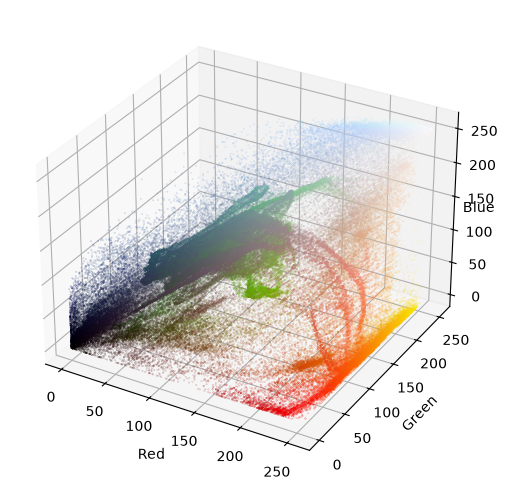

In [5]:
fig, ax = plt.subplots(
    subplot_kw={"projection": "3d"},
    figsize=(12, 5)
)

colors = pixel_data.reshape(-1, pixel_data.shape[-1]) / 255

ax.scatter(pixel_data[:, :, 0], pixel_data[:, :, 1], pixel_data[:, :, 2], s=0.01, c=colors)
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue", labelpad=-10)
fig.subplots_adjust(right=0.85)

plt.tight_layout()
plt.show()

In [6]:
model = KMeans(n_clusters=6)
X = pixel_data.reshape(-1, pixel_data.shape[-1])

model.fit(X)

centers = model.cluster_centers_
centers

array([[212.12419278, 152.99435796, 120.16090001],
       [ 46.90995329,  67.70676801,  66.53383279],
       [117.18471773, 149.30116464, 128.75349307],
       [204.58716789, 214.81916145, 222.51483248],
       [235.97693588, 110.51569212,  11.61379204],
       [ 86.2307497 , 119.12101483,  92.87272859]])

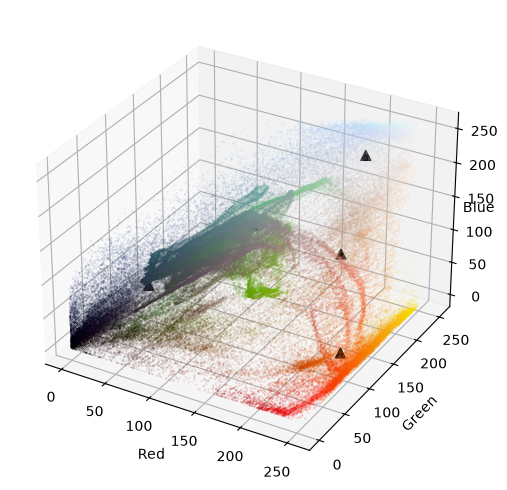

In [7]:
fig, ax = plt.subplots(
    subplot_kw={"projection": "3d"},
    figsize=(12, 5)
)

colors = pixel_data.reshape(-1, pixel_data.shape[-1]) / 255

ax.scatter(pixel_data[:, :, 0], pixel_data[:, :, 1], pixel_data[:, :, 2], s=0.01, c=colors, alpha=0.8)
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=50, c="black", marker="^")
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue", labelpad=-10)
fig.subplots_adjust(right=0.85)

plt.tight_layout()
plt.show()
plt.show()

In [8]:
modified_pixel_data = model.predict(X)
modified_pixel_data = np.array([centers[modified_pixel_data[i]] for i in range(modified_pixel_data.shape[0])], dtype="uint8")
modified_pixel_data = modified_pixel_data.reshape(-1, pixel_data.shape[1], 3)
modified_pixel_data

array([[[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]],

       [[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]],

       [[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]],

       ...,

       [[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]],

       [[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]],

       [[ 86, 119,  92],
        [ 86, 119,  92],
        [ 86, 119,  92],
        ...,
        [117, 149, 128],
        [117, 149, 128],
        [117, 149, 128]]

In [10]:
compressed_img = Image.fromarray(modified_pixel_data)
compressed_img.save("output-butterfly.png")